Image Restoration for Surveillance System

---- Performance ----
Gaussian Noise Restoration
Mean PSNR: 31.802086283076388
Median PSNR: 31.23786050366761
Gaussian PSNR: 31.247494473845713

Salt & Pepper Restoration
Mean PSNR: 31.600429444229743
Median PSNR: 36.350591659042315
Gaussian PSNR: 32.20524429132391


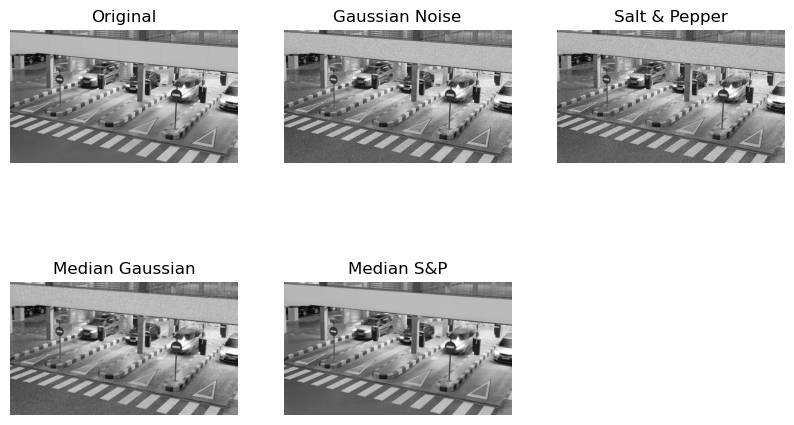

In [ ]:
"""
Name: Sahil Bhardwaj
Course: Image Processing & Computer Vision
Assignment: Noise Modeling and Image Restoration
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("Image Restoration for Surveillance System")

# ---------- Create outputs folder ----------
os.makedirs("outputs", exist_ok=True)

# ---------- Load Image ----------
img = cv2.imread(r"C:\Users\risha\restoration_project\sample_images\sample image.jpg")

if img is None:
    print("Image not found")
    exit()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

cv2.imwrite("outputs/original.png", gray)

# ---------- Add Gaussian Noise ----------
gaussian = gray + np.random.normal(0, 25, gray.shape)
gaussian = np.clip(gaussian, 0, 255).astype(np.uint8)

cv2.imwrite("outputs/gaussian_noise.png", gaussian)

# ---------- Add Salt & Pepper Noise ----------
sp = gray.copy()
prob = 0.02

salt = np.random.rand(*gray.shape) < prob
pepper = np.random.rand(*gray.shape) < prob

sp[salt] = 255
sp[pepper] = 0

cv2.imwrite("outputs/sp_noise.png", sp)

# ---------- Restoration Filters ----------
mean_g = cv2.blur(gaussian,(5,5))
median_g = cv2.medianBlur(gaussian,5)
gauss_g = cv2.GaussianBlur(gaussian,(5,5),0)

mean_sp = cv2.blur(sp,(5,5))
median_sp = cv2.medianBlur(sp,5)
gauss_sp = cv2.GaussianBlur(sp,(5,5),0)

cv2.imwrite("outputs/mean_gaussian.png", mean_g)
cv2.imwrite("outputs/median_gaussian.png", median_g)
cv2.imwrite("outputs/gaussian_gaussian.png", gauss_g)

cv2.imwrite("outputs/mean_sp.png", mean_sp)
cv2.imwrite("outputs/median_sp.png", median_sp)
cv2.imwrite("outputs/gaussian_sp.png", gauss_sp)

# ---------- Metrics ----------
def mse(a,b):
    return np.mean((a-b)**2)

def psnr(a,b):
    m = mse(a,b)
    if m == 0:
        return 100
    return 20*np.log10(255/np.sqrt(m))

print("\n---- Performance ----")

print("Gaussian Noise Restoration")
print("Mean PSNR:", psnr(gray,mean_g))
print("Median PSNR:", psnr(gray,median_g))
print("Gaussian PSNR:", psnr(gray,gauss_g))

print("\nSalt & Pepper Restoration")
print("Mean PSNR:", psnr(gray,mean_sp))
print("Median PSNR:", psnr(gray,median_sp))
print("Gaussian PSNR:", psnr(gray,gauss_sp))

# ---------- Display ----------
plt.figure(figsize=(10,6))
plt.subplot(2,3,1); plt.title("Original"); plt.imshow(gray,cmap="gray"); plt.axis("off")
plt.subplot(2,3,2); plt.title("Gaussian Noise"); plt.imshow(gaussian,cmap="gray"); plt.axis("off")
plt.subplot(2,3,3); plt.title("Salt & Pepper"); plt.imshow(sp,cmap="gray"); plt.axis("off")
plt.subplot(2,3,4); plt.title("Median Gaussian"); plt.imshow(median_g,cmap="gray"); plt.axis("off")
plt.subplot(2,3,5); plt.title("Median S&P"); plt.imshow(median_sp,cmap="gray"); plt.axis("off")

plt.show()